In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alexhuitron/supermarket-sales/supermarket_sales.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv('/kaggle/input/datasets/alexhuitron/supermarket-sales/supermarket_sales.csv')

In [4]:
df.head()

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='object')

In [6]:
highest_product_line= df['product_line'].value_counts()
highest_product_line

product_line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

In [7]:
highest_product_line.index[0]

'Fashion accessories'

In [8]:
df.groupby('branch')['revenue'].sum().sort_values(ascending= False)

branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: revenue, dtype: float64

In [9]:
df['rating'].mean()

np.float64(6.9727)

## Which branch recorded the highest total sales?

In [10]:
branch_revenue= df.groupby('branch')['revenue'].sum().sort_values(ascending= False)
branch_revenue

branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: revenue, dtype: float64

## What is the average customer rating?

In [11]:
df['rating'].mean()

np.float64(6.9727)

## Which payment method is used most frequently?

In [12]:
payments= df['payment_method'].value_counts()
payments

payment_method
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

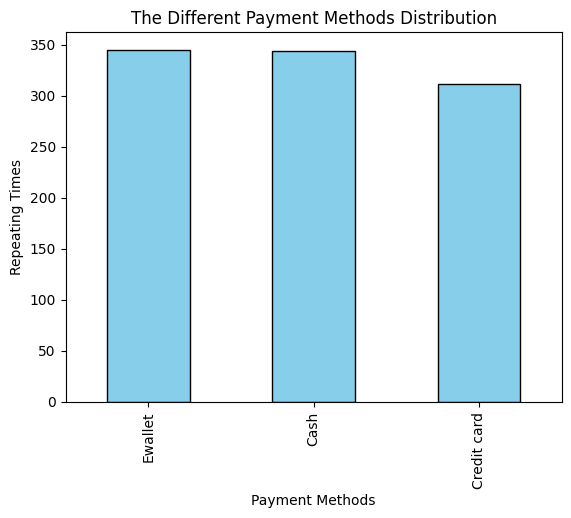

In [13]:
payments.plot(kind= 'bar', color= 'skyblue', edgecolor= 'black')
plt.title('The Different Payment Methods Distribution')
plt.xlabel('Payment Methods')
plt.ylabel('Repeating Times')
plt.show()